## Visualisation using Python (SAC-Sprint 2)

In [1]:
# SECTION 0- INSTALL PACKAGES (Run Once)
!pip install mysql-connector-python
!pip install pandas 
!pip install matplotlib 
!pip install seaborn 

In [31]:
# SECTION 1 - IMPORT REQUIRED LIBRARIES
import pandas as pd
import mysql.connector
import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
# SECTION 2 - GLOBAL VISUALIZATION SETTINGS

# Consistent theme across all visualizations

sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (12,6)
plt.rcParams["font.size"] = 11
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

In [33]:
# SECTION 3 - DATABASE FUNCTIONS
# Purpose:
# Avoid repeating database connection code.
# Create reusable functions for:
# 1. Connecting to MySQL
# 2. Running SQL queries



# Define function:  1. Connecting to MySQL
def create_connection():
    """
    Create connection to StreamflixDB
    """

    connection = mysql.connector.connect(
        host="localhost",
        user="root",
        password="Test12345mysql", #enter your own password
        database="StreamflixDB"  # eneter your database
    )

    return connection


# Define function: 2. Running SQL queries
def execute_query(query):
    """
    Execute SQL query and return DataFrame
    """

    connection = create_connection()

    df = pd.read_sql(query, connection)

    connection.close()

    return df

In [34]:
# OPTIONAL- ONLY IN MY LAPTOP
import warnings

warnings.filterwarnings(
    'ignore',
    message='pandas only supports SQLAlchemy connectable*'
)

In [35]:
# SECTION 4 - TEST DATABASE CONNECTION
#
# Purpose:
# Verify Python can communicate with MySQL.

print("=" * 60)
print("TESTING DATABASE CONNECTION")
print("=" * 60)

tables = execute_query("SHOW TABLES")

display(tables)

print("\nDatabase connection successful.\n")


TESTING DATABASE CONNECTION


,Tables_in_streamflixdb
0,movies
1,ratings
2,users



Database connection successful.



## VISUALIZATION 1: TOP 10 MOVIES BY AVERAGE RATING

In [36]:
# Step 1: Query Data from MySQL
query = """
SELECT
    m.Title,
    ROUND(AVG(r.Rating),2) AS AverageRating,
    COUNT(r.Rating) AS RatingCount
FROM Movies m
JOIN Ratings r
    ON m.MovieID = r.MovieID
GROUP BY m.MovieID, m.Title
HAVING COUNT(r.Rating) >= 5   ######IMPRTANT! SET RATING COUNT 
ORDER BY 
    AverageRating DESC,
    RatingCount DESC
LIMIT 10;
"""
df = execute_query(query)

print("Rows returned:", len(df))
display(df)


Rows returned: 10


,Title,AverageRating,RatingCount
0,Remember the Titans,4.62,5
1,High Plains Drifter,4.26,5
2,"Nightmare on Elm Street, A",4.14,5
3,SubUrbia,4.02,5
4,"$1,000,000 Duck",4.02,5
5,Private Parts,3.96,5
6,B. Monkey,3.96,5
7,"Mountain Eagle, The",3.95,6
8,Mr. Smith Goes to Washington,3.94,7
9,"Replacement Killers, The",3.92,6


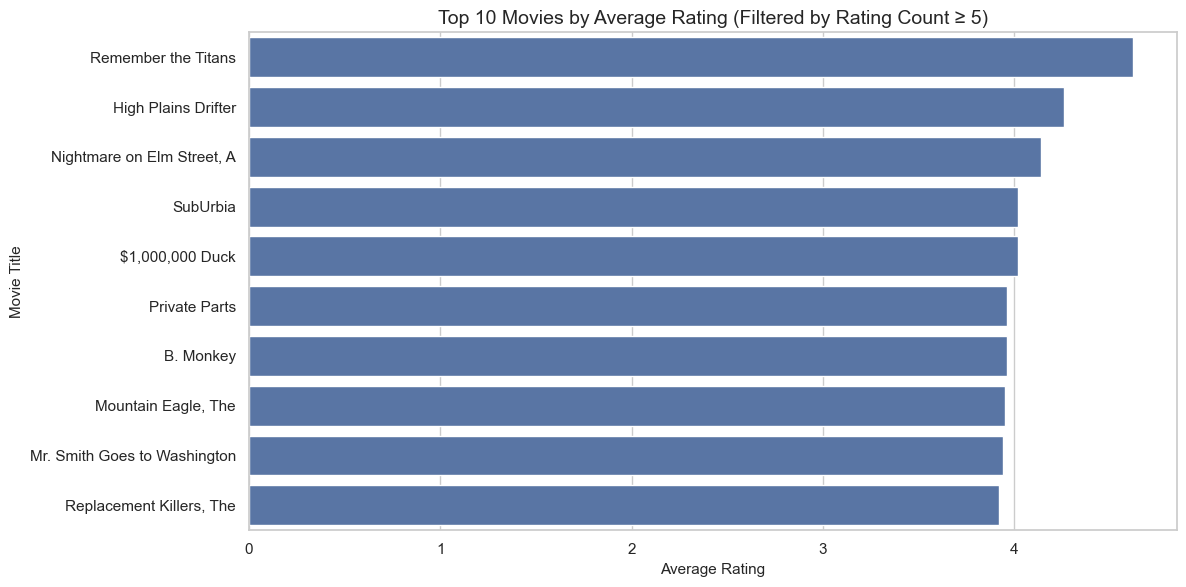

In [37]:
# Step 2. Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

sns.barplot(
    data=df,
    x="AverageRating",
    y="Title"
)

plt.title("Top 10 Movies by Average Rating (Filtered by Rating Count ≥ 5)")
plt.xlabel("Average Rating")
plt.ylabel("Movie Title")

plt.tight_layout()
plt.show()

## VISUALISATION 2: MOST POPULAR GENRES (by Total views)

In [38]:
query = """
SELECT Genres, TotalViews
FROM Movies;
"""

data = execute_query(query)

# =========================
# STEP 2: CREATE DATAFRAME
# =========================
df = pd.DataFrame(data, columns=["Genres", "TotalViews"])

# Ensure numeric type (important fix)
df["TotalViews"] = pd.to_numeric(df["TotalViews"], errors="coerce")

# =========================
# STEP 3: SPLIT GENRES
# =========================
df["Genres"] = df["Genres"].str.split("|")
df = df.explode("Genres")

# =========================
# STEP 4: AGGREGATE
# =========================
genre_views = df.groupby("Genres", as_index=False)["TotalViews"].sum()

# Sort + Top 10 (recommended for assignment clarity)
genre_views = genre_views.sort_values("TotalViews", ascending=False).head(10)

display(genre_views)

,Genres,TotalViews
7,DRAMA,79984842
4,COMEDY,61010936
0,ACTION,24971668
15,THRILLER,24943349
13,ROMANCE,23774033
10,HORROR,17690325
1,ADVENTURE,14161019
14,SCI-FI,13018648
3,CHILDREN'S,12944907
5,CRIME,9998474


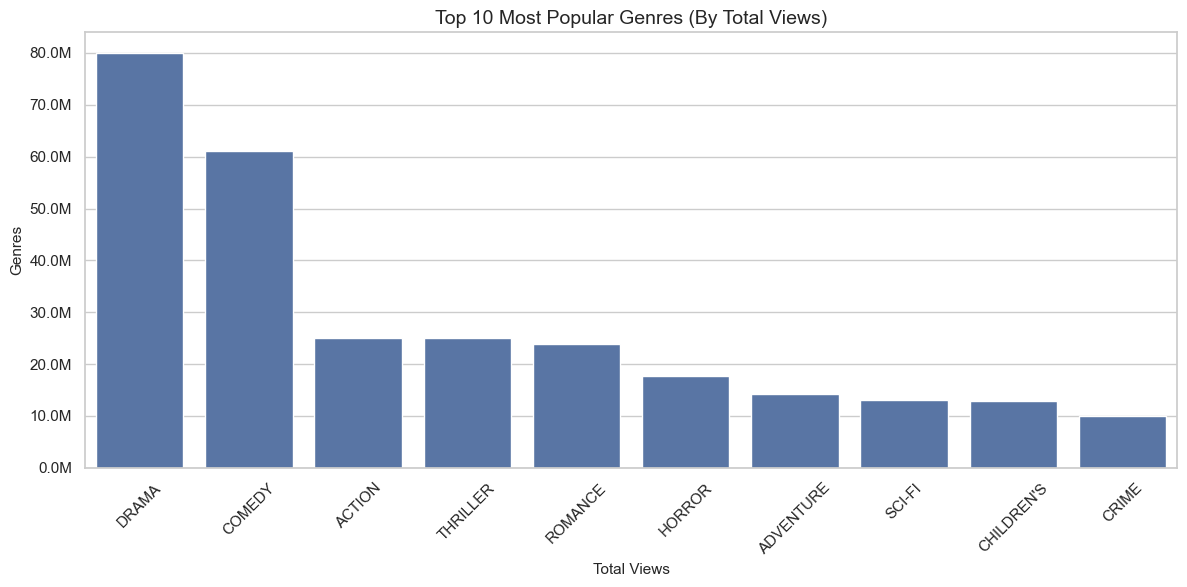

In [39]:
#Step 3. Visualisation
plt.figure(figsize=(12,6))

sns.barplot(
    data=genre_views,
    y="TotalViews",
    x="Genres"
)

plt.title("Top 10 Most Popular Genres (By Total Views)")
plt.xlabel("Total Views")
plt.ylabel("Genres")

# convert axis to millions
import matplotlib.ticker as mtick

plt.gca().yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f'{x/1_000_000:.1f}M')
)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## VISUALIZATION 3: USER DISTRIBUTION BY AGE GROUP

In [40]:
# Step 1: Query Data from MySQL
query = """
SELECT Age
FROM Users;
"""

age_df = execute_query(query)

bins = [0,11,21,31,41,51,61,71]

labels = [
    "Children (0-10)",
    "Teenagers (11-20)",
    "Young Adults (21-30)",
    "Adults (31-40)",
    "Middle-Aged Adults (41-50)",
    "Older Adults (51-60)",
    "Senior (61+)"
]

age_df["AgeGroup"] = pd.cut(
    age_df["Age"],
    bins=bins,
    labels=labels
)

age_summary = (
    age_df["AgeGroup"]
    .value_counts()
    .sort_index()
    .reset_index()
)

age_summary.columns = ["AgeGroup","TotalUsers"]

display(age_summary)

,AgeGroup,TotalUsers
0,Children (0-10),310
1,Teenagers (11-20),1029
2,Young Adults (21-30),1051
3,Adults (31-40),1069
4,Middle-Aged Adults (41-50),1126
5,Older Adults (51-60),1044
6,Senior (61+),411


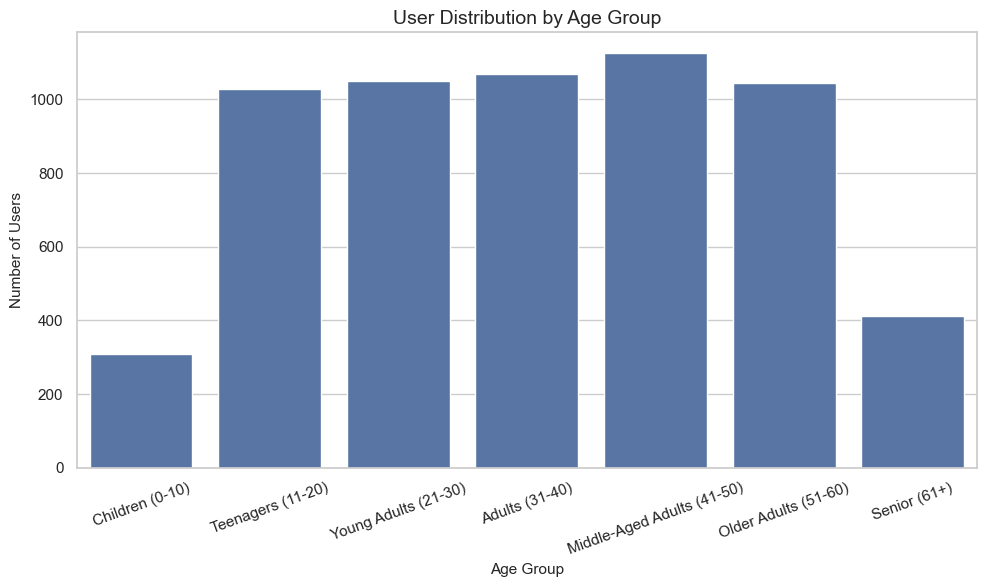

In [41]:
# Step 2. Visualisation
plt.figure(figsize=(10,6))

sns.barplot(
    data=age_summary,
    x="AgeGroup",
    y="TotalUsers"
)

plt.title("User Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Users")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()


## VISUALIZATION 4: DISTRIBUTION OF USERS BY SUBSCRIPTION STATUS

In [42]:
# Step 1: Query Data from MySQL
query = """
SELECT
    SubscriptionStatus,
    COUNT(*) AS TotalUsers
FROM Users
GROUP BY SubscriptionStatus;
"""

subscription_df = execute_query(query)

display(subscription_df)

,SubscriptionStatus,TotalUsers
0,FREE,3084
1,SUBSCRIBER,2956


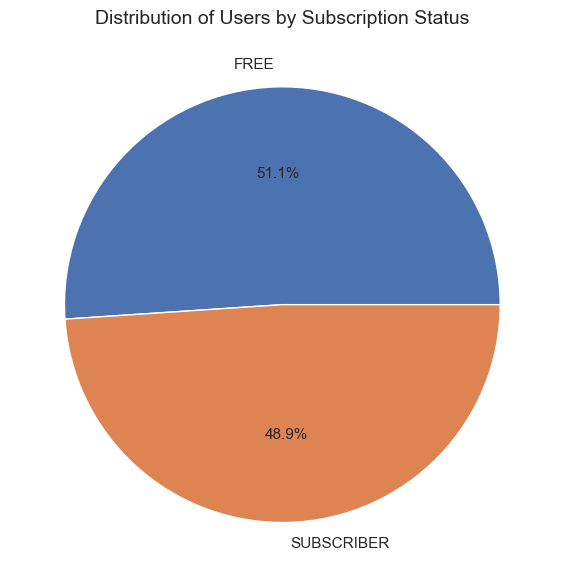

In [43]:
# Step 2. Visualisation: Option 01 (PIE)

#plt.figure(figsize=(8,8))

plt.pie(
    subscription_df["TotalUsers"],
    labels=subscription_df["SubscriptionStatus"],
    autopct="%1.1f%%"
)

plt.title("Distribution of Users by Subscription Status")

plt.tight_layout()
plt.show()

## VISUALIZATION 5: USER DISTRIBUTION BY COUNTRY

In [44]:
# Step 1: Query Data from MySQL
query = """
SELECT
    Country,
    COUNT(*) AS TotalUsers
FROM Users
GROUP BY Country
ORDER BY TotalUsers DESC;
"""

country_df = execute_query(query)

display(country_df)

,Country,TotalUsers
0,CANADA,1034
1,USA,1022
2,INDIA,1021
3,ITALY,1016
4,FRANCE,986
5,UK,961


<Figure size 1200x600 with 0 Axes>

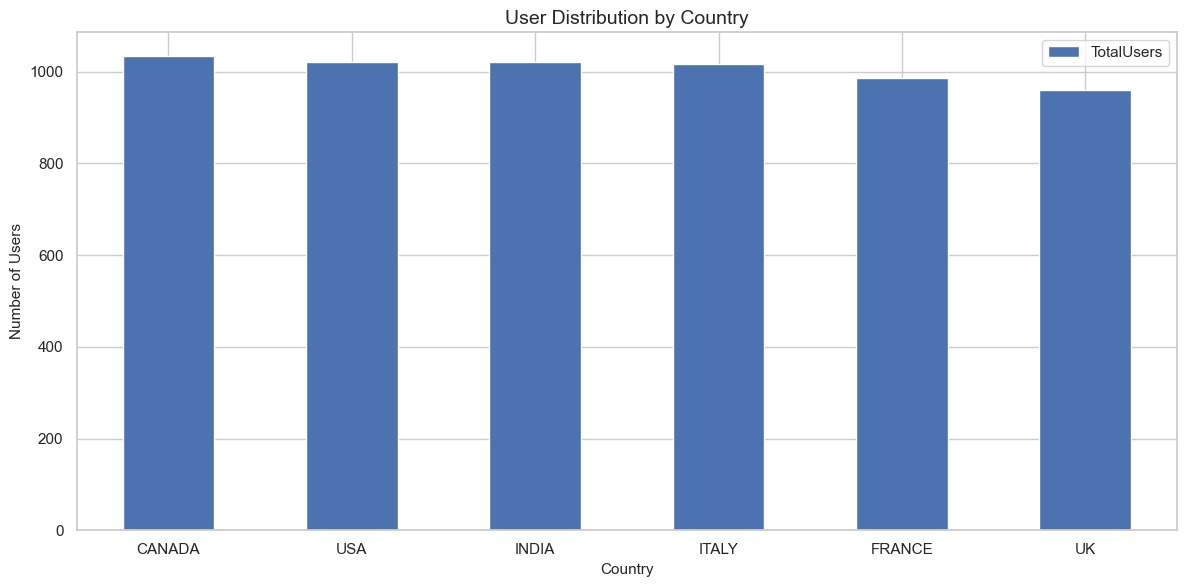

In [45]:
#Step 2. Visualisation (Option 02)
plt.figure(figsize=(12,6))

country_df.plot(kind='bar',x="Country", y="TotalUsers" )

plt.title("User Distribution by Country")
plt.xlabel("Country")
plt.ylabel("Number of Users")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## VISUALIZATION 6: DISTRIBUTION OF DEVICE USAGE AMONG USERS

In [46]:
# Step 1: Query Data from MySQL
query = """
SELECT
    Device,
    COUNT(*) AS TotalUsers
FROM Users
GROUP BY Device
ORDER BY TotalUsers DESC;
"""

device_df = execute_query(query)

display(device_df)


,Device,TotalUsers
0,MOBILE,1549
1,SMART TV,1499
2,DESKTOP,1497
3,TABLET,1495


<Figure size 1200x600 with 0 Axes>

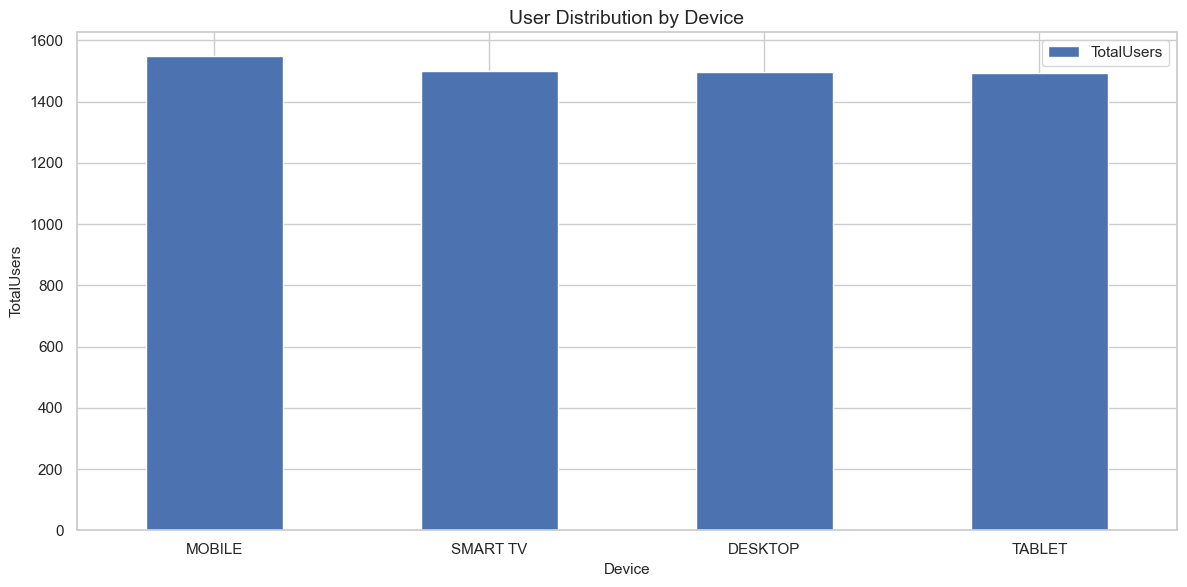

In [47]:
# Step 2. Visualisation -OPTION 03 (bar)

plt.figure(figsize=(12,6))

device_df.plot(kind='bar',x="Device", y="TotalUsers" )

plt.title("User Distribution by Device")
plt.xlabel("Device")
plt.ylabel("TotalUsers")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [48]:
# CLOSING STATEMENT
print("="*60)
print("STREAMFLIX TASK 8 COMPLETED")
print("All SQL Queries Executed Successfully")
print("All Visualizations Generated Successfully")
print("="*60)

STREAMFLIX TASK 8 COMPLETED
All SQL Queries Executed Successfully
All Visualizations Generated Successfully
